# Expression of Methylation Toolkit Genes
Plotting expression of the methylation toolkit genes I was able to find in the *C. virginica* genome (from [methyl_toolkit.ipynb](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/methylation_toolkit/methyl_toolkit_genes.csv))

## 0. load libraries

In [83]:
library(tidyverse)
library(RColorBrewer)
library(pheatmap)
library(cowplot) # for combining plots
library(ggh4x) # explicit control over ggplot

## 1. read csvs

### vst
for this, since I want to look at both phase 1 and phase 2 oysters togheter, I'm going to use the [VST csv](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/compare_phases/outputs/vst_allSamples.csv) produced from running DESeq on all oysters ([deseq_wgcna_all.ipynb](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/compare_phases/deseq_wgcna_ALL.ipynb))

In [118]:
vst <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/compare_phases/outputs/vst_allSamples.csv')
colnames(vst)[1] <- 'Gene'
head(vst)

,Gene,B1_B1_O01,B1_Nu_O03,B1_W5_O50,B2_B5_O51,B2_C4_O40,B2_Nu_O12,B3_B4_O41,B3_C3_O30,B3_C6_O66,⋯,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_Nu_G41,W6_Nu_G45,W6_W3_G36,W6_W4_G48
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,11.666953,11.269656,11.453130,11.444343,11.345947,11.890737,11.034822,11.041739,11.436993,⋯,11.162800,11.57553,11.467739,11.269554,11.435389,11.280532,11.471606,11.572800,11.901560,11.714980
2,LOC144621269,9.122483,9.978336,11.198837,11.600233,10.642966,13.983392,11.629168,10.766306,12.883508,⋯,8.793511,10.32771,9.065006,9.343892,13.522189,8.903466,8.682617,12.194809,10.069397,13.496908
3,LOC111120925,9.189670,8.710781,8.943717,10.081693,8.823398,8.864449,8.896728,8.803116,8.591124,⋯,8.734292,10.09588,9.235584,8.990707,8.770431,8.669352,8.591124,8.831908,8.852397,8.822230
4,LOC144621283,10.221698,10.353835,10.591036,10.616577,10.485275,10.555235,10.537629,10.814204,10.796697,⋯,10.505011,10.61570,10.607791,10.510067,10.295269,11.071990,10.502580,10.518313,10.329065,10.334013
5,LOC144621276,13.503236,13.272327,13.526015,13.702913,13.581633,13.538128,13.802742,13.954562,13.791216,⋯,13.902072,13.57964,13.166142,13.312381,14.001776,13.436827,13.650792,13.287784,13.530107,13.441619
6,LOC111115920,9.512109,9.712293,9.564160,9.481098,9.359553,9.612035,9.278306,9.242035,9.168801,⋯,9.730705,9.43289,10.013911,9.999569,9.580243,9.715006,9.451265,9.296234,9.319159,9.403732


### meta data

In [119]:
meta <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/sample_metaData.csv')
head(meta)

,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1
2,B1_Nu_O03,both,warm,hypoxic,1,NA,NA,NA,NA
3,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5
4,B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5
5,B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4
6,B2_Nu_O12,both,warm,hypoxic,2,NA,NA,NA,NA


### methylation toolkit genes

In [120]:
methyl_genes <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/methylation_toolkit/methyl_toolkit_genes.csv') %>%
# remove missing genes
na.omit() %>%
rename('Gene' =  gene_id)

head(methyl_genes)

,gene_common,Gene,description,present,Function
,<chr>,<chr>,<chr>,<chr>,<chr>
1,DNMT1,LOC111121210,DNA methyltransferase 1-associated protein 1-like,Yes,Writer
2,DNMT2,LOC111125611,tRNA (cytosine(38)-C(5))-methyltransferase-like,Yes,Writer
3,DNMT3B,LOC111122163,DNA (cytosine-5)-methyltransferase 3B-like,Yes,Writer
6,TET1,LOC111118472,methylcytosine dioxygenase TET1-like,Yes,Eraser
10,MBD2,LOC111128560,methyl-CpG-binding domain protein 2-like,Yes,Reader
12,MBD4,LOC111107813,methyl-CpG-binding domain protein 4-like,Yes,Reader


## 2. data formatting
pull methylation genes, add meta data

In [121]:
methyl.vst <- vst[vst$Gene %in% methyl_genes$Gene,] %>%
pivot_longer(
    cols = -Gene,
    names_to = 'Sample',
    values_to = 'vst_expr'
    )

# add meta data to vst info
methyl.df <- merge(methyl.vst, meta, by = 'Sample') %>%
# add column to denote phase
mutate(phase = case_when(
    is.na(Phase2_treatment)  ~ 'Phase 1',
    .default    = 'Phase 2')) 

# add annotation info
methyl.df <- merge(methyl.df, methyl_genes, by = 'Gene')

# replace NA for treatment with none
methyl.df$Phase2_treatment[is.na(methyl.df$Phase2_treatment)] <- "none"


head(methyl.df)

,Gene,Sample,vst_expr,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,phase,gene_common,description,present,Function
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
1,LOC111107813,H1_C6_B62,10.49510,hypoxic,ambient,hypoxic,1,control,ambient,normoxic,6,Phase 2,MBD4,methyl-CpG-binding domain protein 4-like,Yes,Reader
2,LOC111107813,B4_C5_O56,10.61310,both,warm,hypoxic,4,control,ambient,normoxic,5,Phase 2,MBD4,methyl-CpG-binding domain protein 4-like,Yes,Reader
3,LOC111107813,B5_H2_O21,10.66308,both,warm,hypoxic,5,hypoxic,ambient,hypoxic,2,Phase 2,MBD4,methyl-CpG-binding domain protein 4-like,Yes,Reader
4,LOC111107813,H5_B1_B09,10.26461,hypoxic,ambient,hypoxic,5,both,warm,hypoxic,1,Phase 2,MBD4,methyl-CpG-binding domain protein 4-like,Yes,Reader
5,LOC111107813,C4_B1_W07,10.66109,control,ambient,normoxic,4,both,warm,hypoxic,1,Phase 2,MBD4,methyl-CpG-binding domain protein 4-like,Yes,Reader
6,LOC111107813,C4_Nu_W29,10.87601,control,ambient,normoxic,4,none,NA,NA,NA,Phase 1,MBD4,methyl-CpG-binding domain protein 4-like,Yes,Reader


set factor levels

In [122]:
methyl.df$Function <- factor(methyl.df$Function, levels = c('Writer', 'Eraser', 'Reader', 'Support', 'Cofactor', 'Demethylation Pathway'))

methyl.df$Phase1_treatment <- factor(methyl.df$Phase1_treatment, levels = c('control', 'hypoxic', 'warm', 'both', 'none'))
methyl.df$Phase2_treatment <- factor(methyl.df$Phase2_treatment, levels = c('control', 'hypoxic', 'warm', 'both', 'none'))

## 3. plot

### all methylation toolkit genes

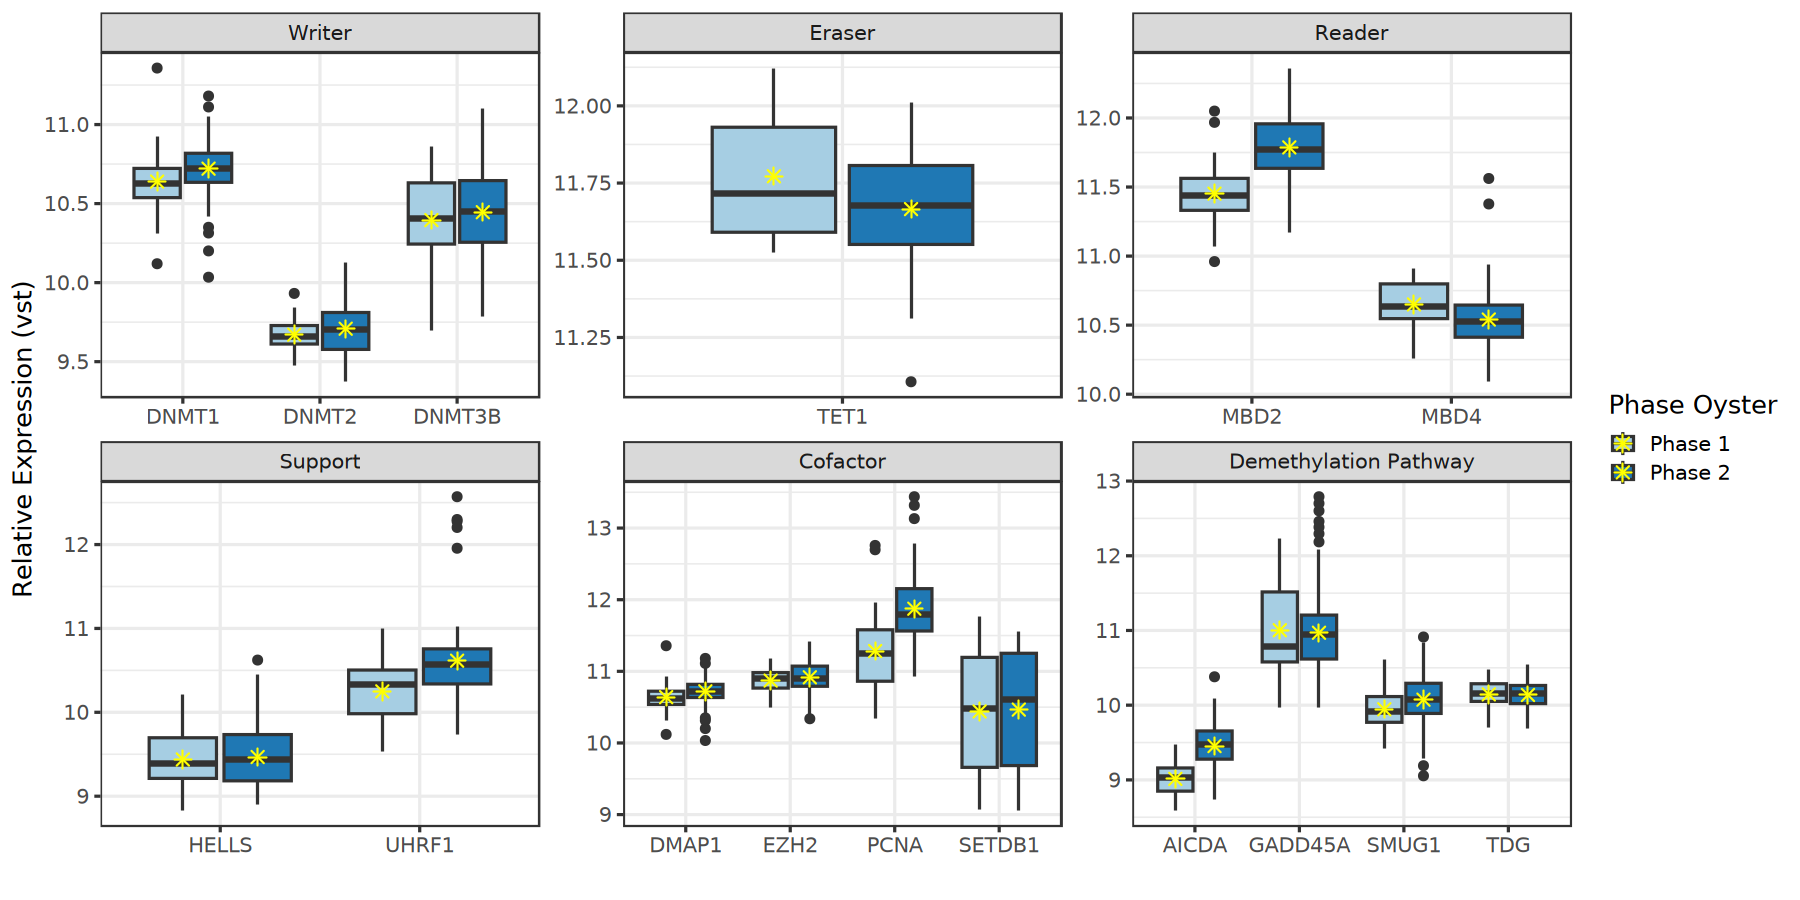

In [158]:
options(repr.plot.height = 7.5, repr.plot.width = 15)

ggplot(methyl.df, aes(x = gene_common, y = vst_expr, fill = phase)) +
geom_boxplot() +
stat_summary(
    fun = "mean", 
    position = position_dodge(width = 0.75),
    geom = "point", 
    shape = 8,      # asterick shape
    size = 3,        # Size of the point
    color = "yellow"  # Outline color
  ) +
facet_wrap(~Function, scales = 'free') +
scale_fill_brewer(palette = 'Paired') +
theme_bw(base_size = 15) +
labs(x = '',
     y = 'Relative Expression (vst)',
     fill = 'Phase Oyster'
     )

**observations**:
- DNMT2 has lower expression compared to the other methylation writers (but otherwise, phase 1 and 2 oysters appear to have similar expression of writers)
- higher average expression in phase 2 oysters for DNMT1, MBD2, UHRF1, PCNA, and AICDA
- higher average expression in phase 1 oysters for TET1 and MBD4

### only writer genes
- DNMT1 = post-replication maintenance
- DNMT2 = targets tRNA
- DNMT3 = de novo methylation

In [124]:
writer.df <- methyl.df %>% filter(Function == 'Writer')

#### phase 1 oysters

In [125]:
writer.p1 <- writer.df %>% filter(phase == 'Phase 1')

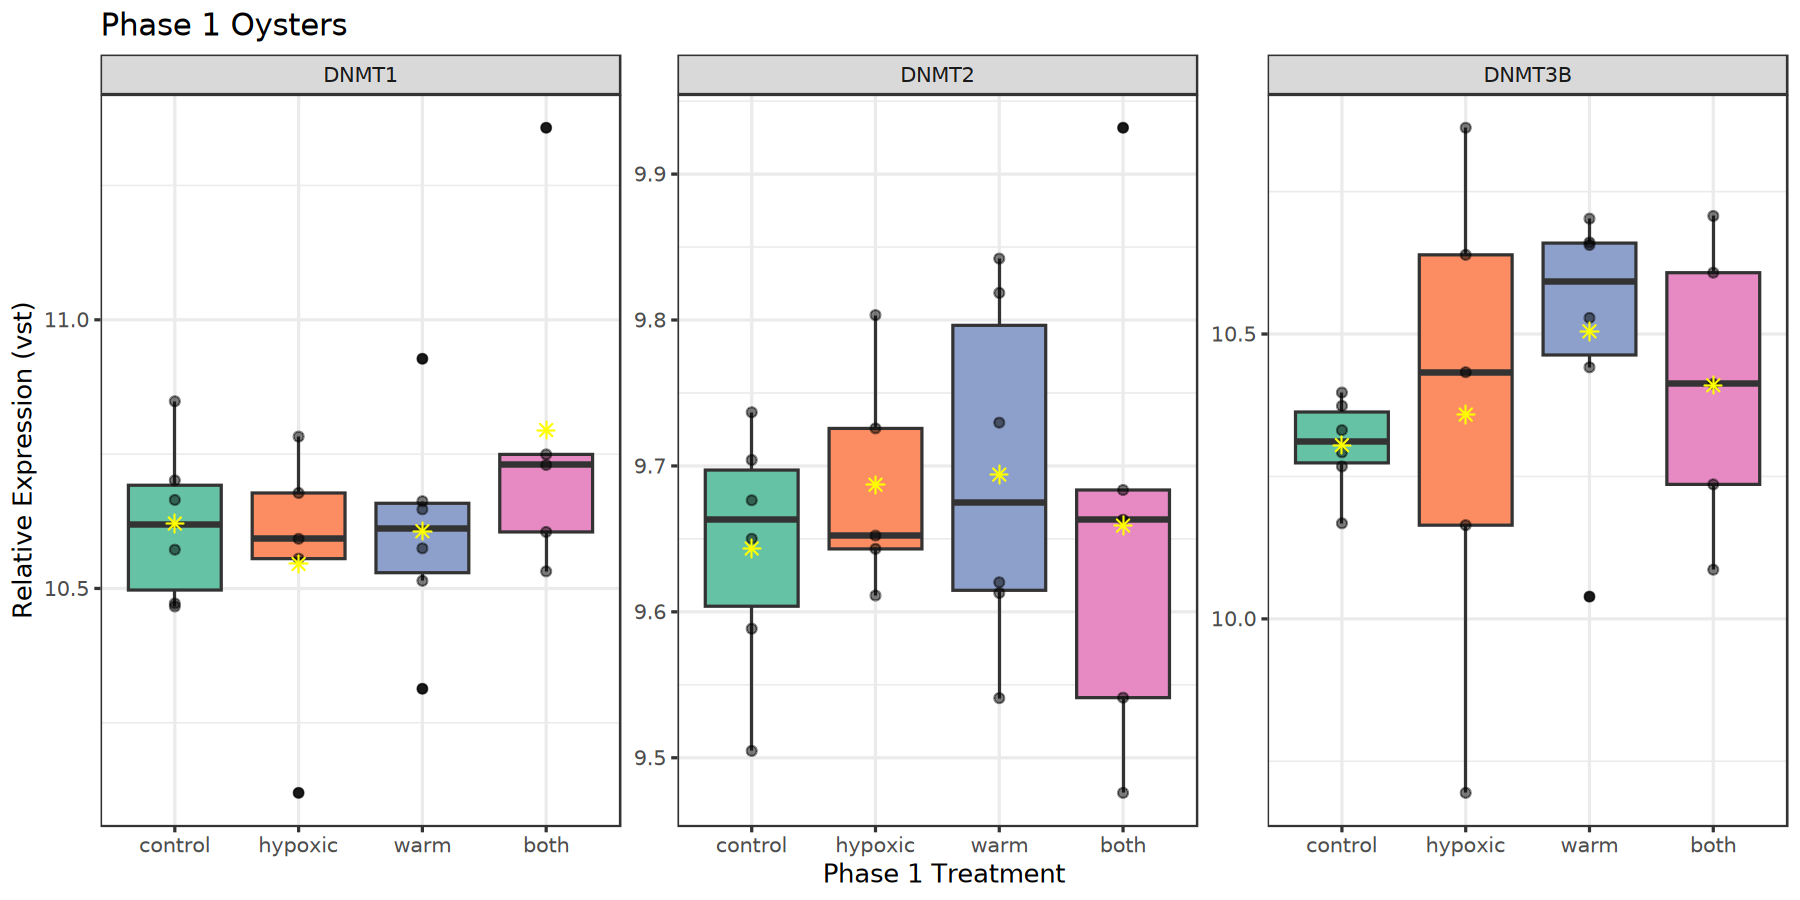

In [157]:
options(repr.plot.height = 7.5, repr.plot.width = 15)

p1_writers.plot <- ggplot(writer.p1,
       aes(x = Phase1_treatment, y = vst_expr, fill = Phase1_treatment)) +
geom_boxplot() +
geom_point(alpha = 0.5) +
stat_summary(
    position = position_dodge(width = 0.75),
    fun = "mean", 
    geom = "point", 
    shape = 8,      # asterick shape
    size = 3,        # Size of the point
    color = "yellow"  # Outline color
  ) +
scale_fill_brewer(palette = 'Set2') +
facet_wrap(~gene_common, scales = 'free') +
theme_bw(base_size = 15) +
guides(fill = 'none') +
labs(
    x = 'Phase 1 Treatment',
    y = 'Relative Expression (vst)',
    title = 'Phase 1 Oysters'
    )

p1_writers.plot

okay cool! i'm seeing higher expression of DNMT3b (de novo methylation) in oysters that experienced stressors compared to control!

and DNMT1 (post-replication maintenance) seem to be similarly expresssed among oysters - so all are maintaining methylation similarly? although both is a little higher, so maybe that indicates there is more methylation that needs to be maintained? those methylation marks are being maintained more than in hypoxic or warm oysters?

#### phase 2 oysters

In [127]:
writer.p2 <- writer.df %>% filter(phase == 'Phase 2')

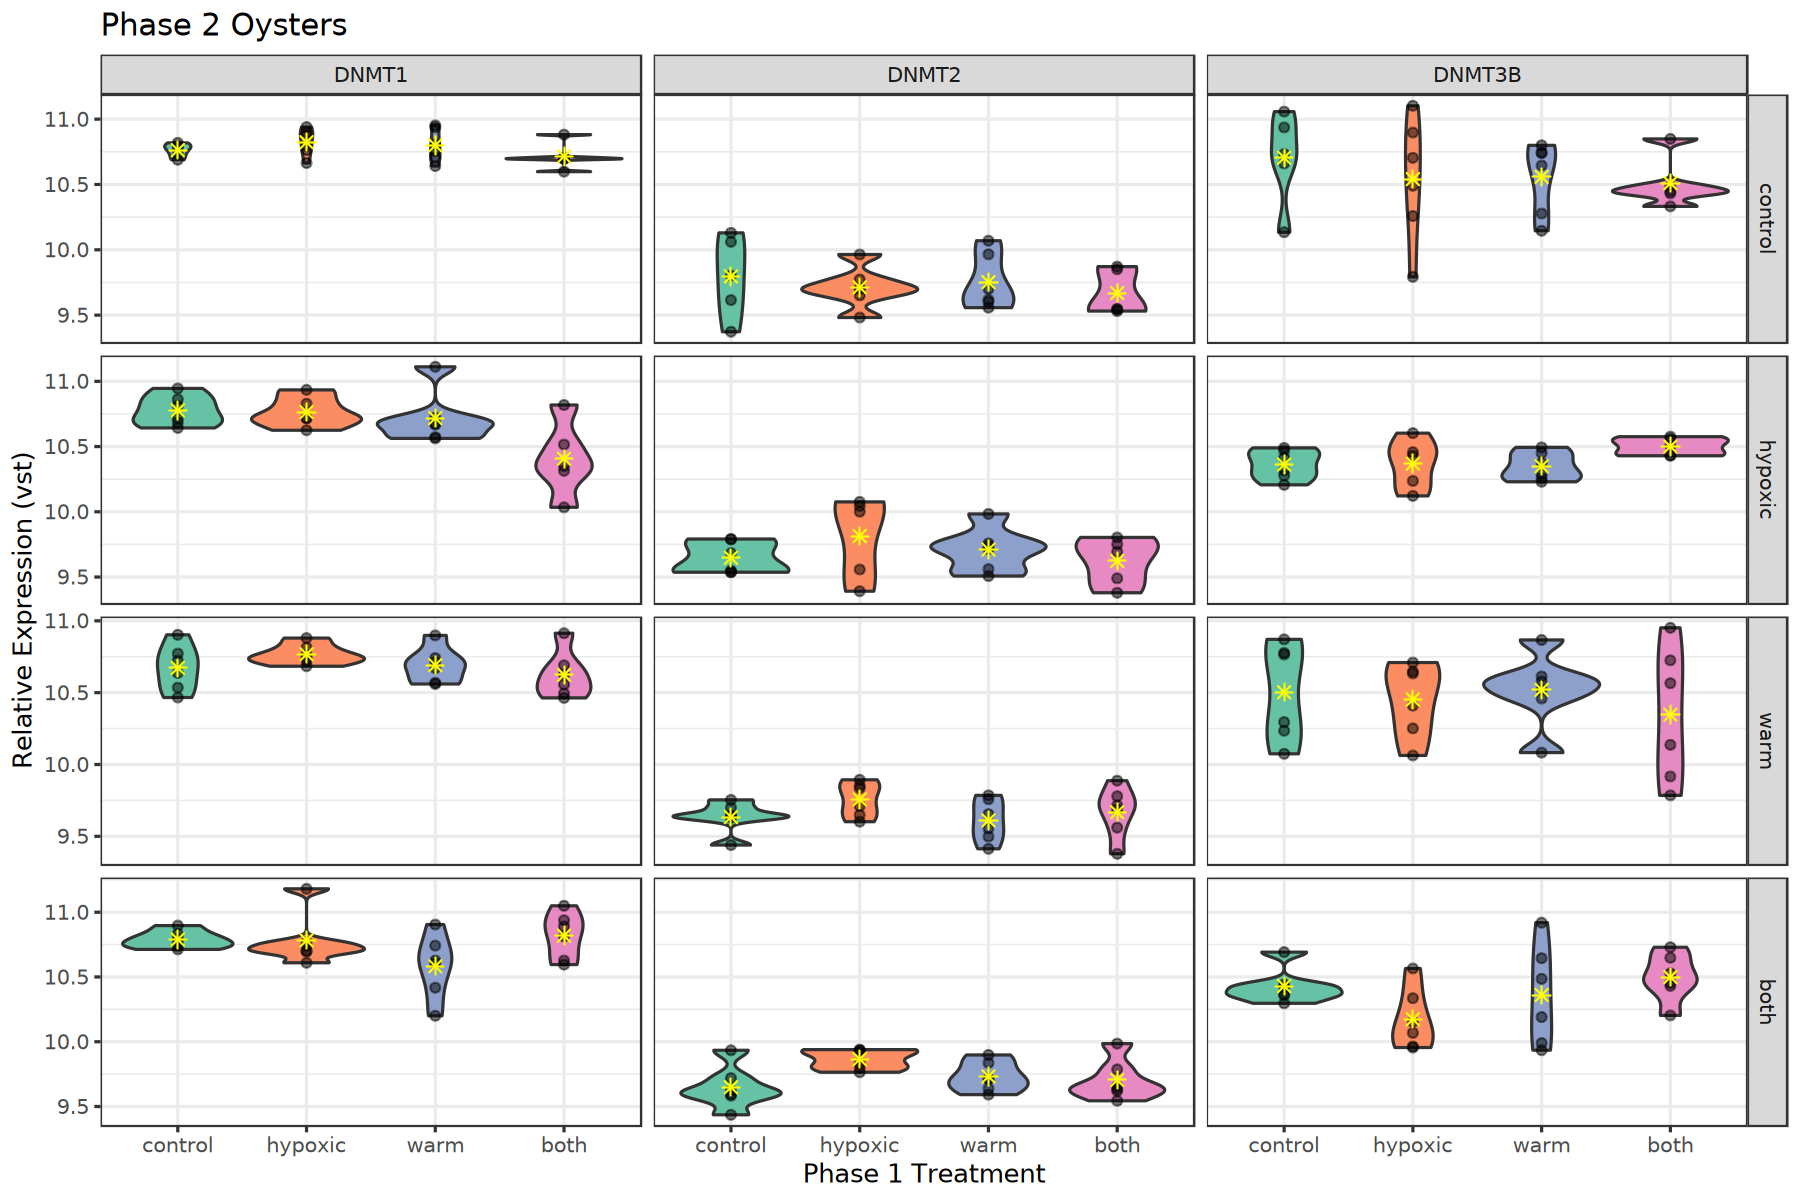

In [128]:
options(repr.plot.height = 10, repr.plot.width = 15)

ggplot(writer.p2,
       aes(x = Phase1_treatment, y = vst_expr, fill = Phase1_treatment)) +
geom_violin() +
geom_point(alpha = 0.5) +
stat_summary(
    fun = "mean", 
    geom = "point", 
    shape = 8,      # asterick shape
    size = 3,        # Size of the point
    color = "yellow"  # Outline color
  ) +
scale_fill_brewer(palette = 'Set2') +
facet_grid(Phase2_treatment~gene_common, scales = 'free') +
theme_bw(base_size = 15) +
guides(fill = 'none') +
labs(
    x = 'Phase 1 Treatment',
    y = 'Relative Expression (vst)',
    title = 'Phase 2 Oysters'
    )

this is a bit hard to follow - I'm trying to visualize phase 2 oyster treatment history and genes at the same time

here, the phase 1 treatment is the x axis and the phase 2 treatments are the rows but I think it's hard to make sense of things right now

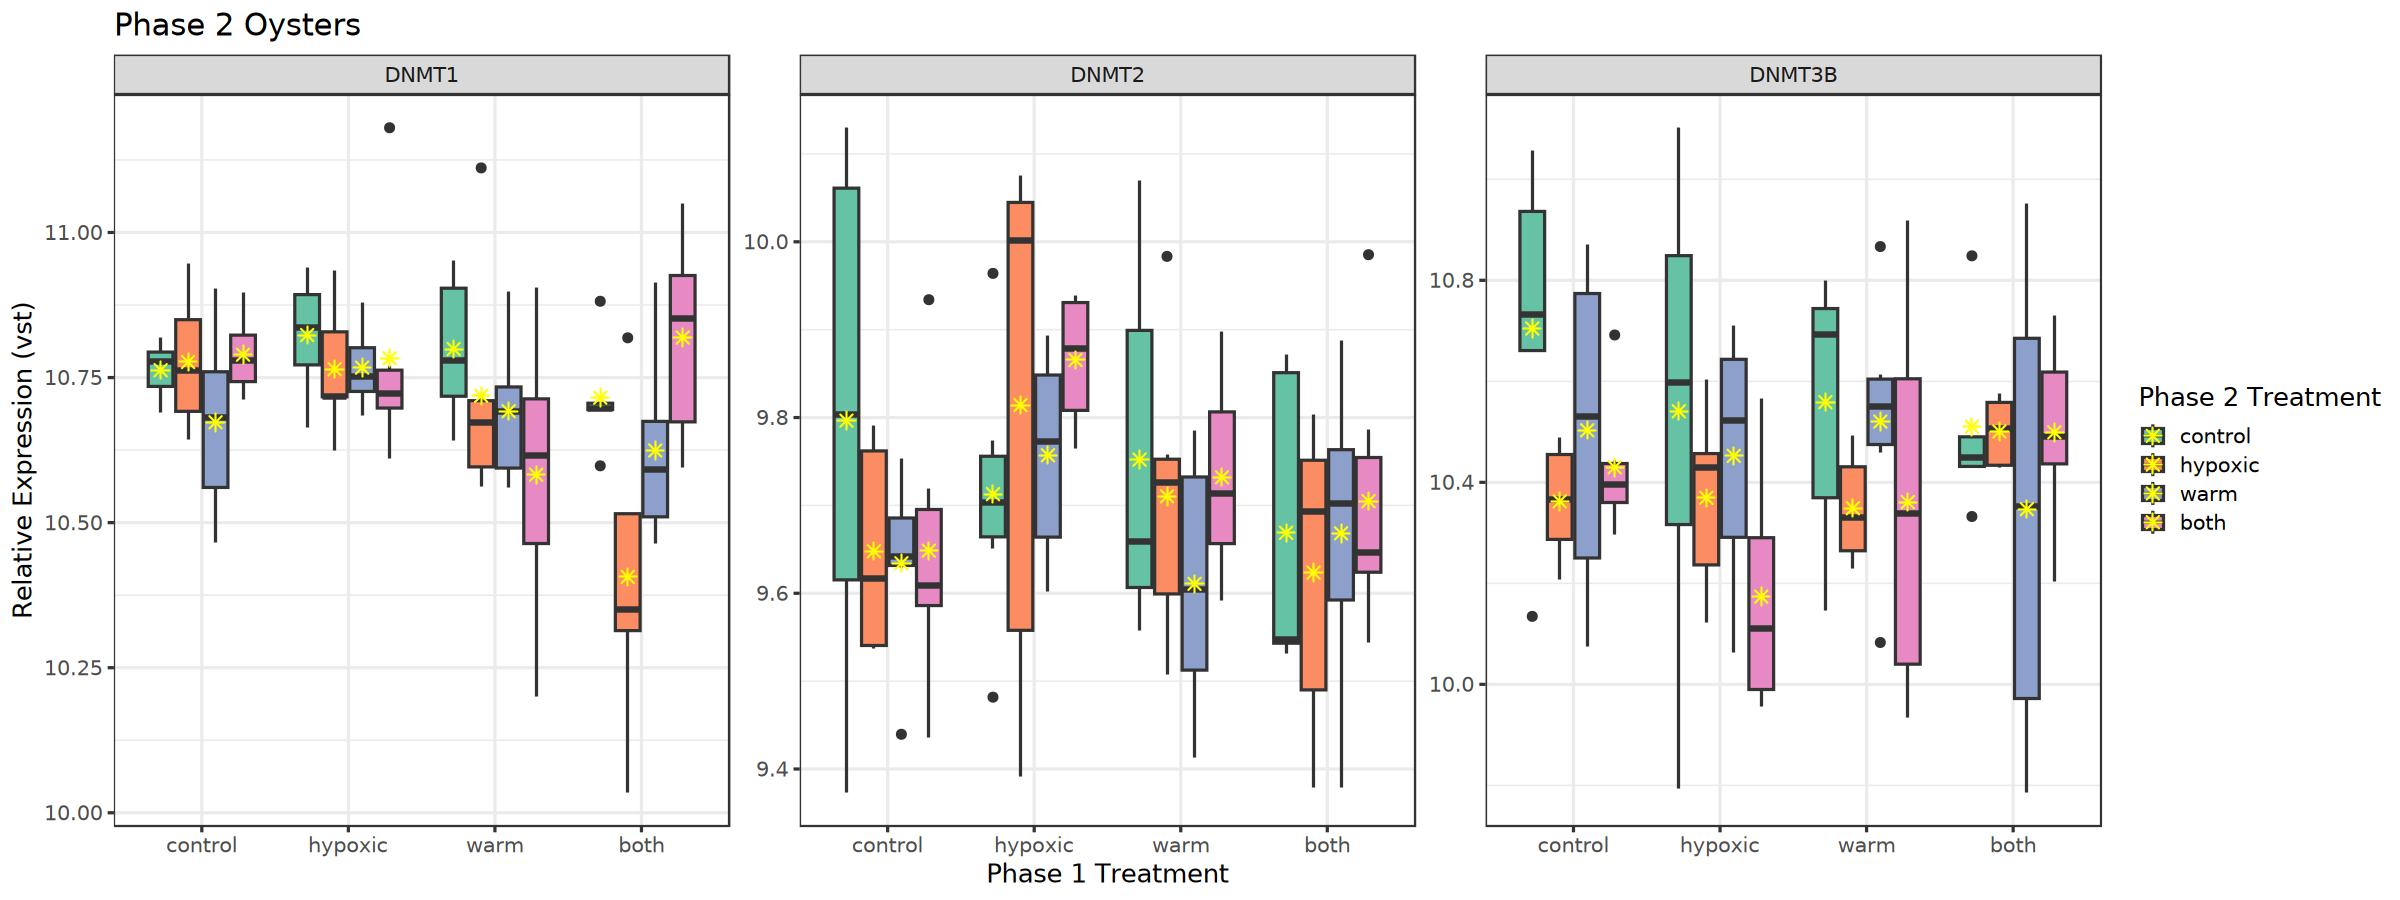

In [129]:
options(repr.plot.height = 7.5, repr.plot.width = 20)

p2_writers.plot <- ggplot(writer.p2,
       aes(x = Phase1_treatment, y = vst_expr, fill = Phase2_treatment)) +
geom_boxplot() +
stat_summary(
    fun = mean,
    geom = "point",
    position = position_dodge(width = 0.75),
    shape = 8,
    size = 3,
    color = "yellow"
  ) +
scale_fill_brewer(palette = 'Set2') +
facet_wrap(~gene_common, scales = 'free') +
theme_bw(base_size = 15) +
labs(
    x = 'Phase 1 Treatment',
    y = 'Relative Expression (vst)',
    fill = 'Phase 2 Treatment',
    title = 'Phase 2 Oysters'
    )

p2_writers.plot

**Above**: Phase 1 is on the x-axis, colored by Phase 2. Yellow astericks = mean expression (mid line of boxplot = median)

appears that most variation is due to the most recent exposure (since there's a lot of variation within a phase 1 treatment)

**observations**:
- DNMT1 (maintenance)
    - oysters that experienced early exposure to both stressors = lots of variation in expression of DNMT1
    - oysters that experienced an early life exposure to warm had decreased expression of DNMT1 in all later life stressors, unless returned to control conditions
- DNMT2 (tRNA methylation)
    - lower expression overall compared to DNMT1 and DNMT3b
    - seems like there's variation in expression within replicate samples
- DNMT3B (de novo)
    - seems like phase 2 control oysters generally have higher expression?

switching the treatment visuals:

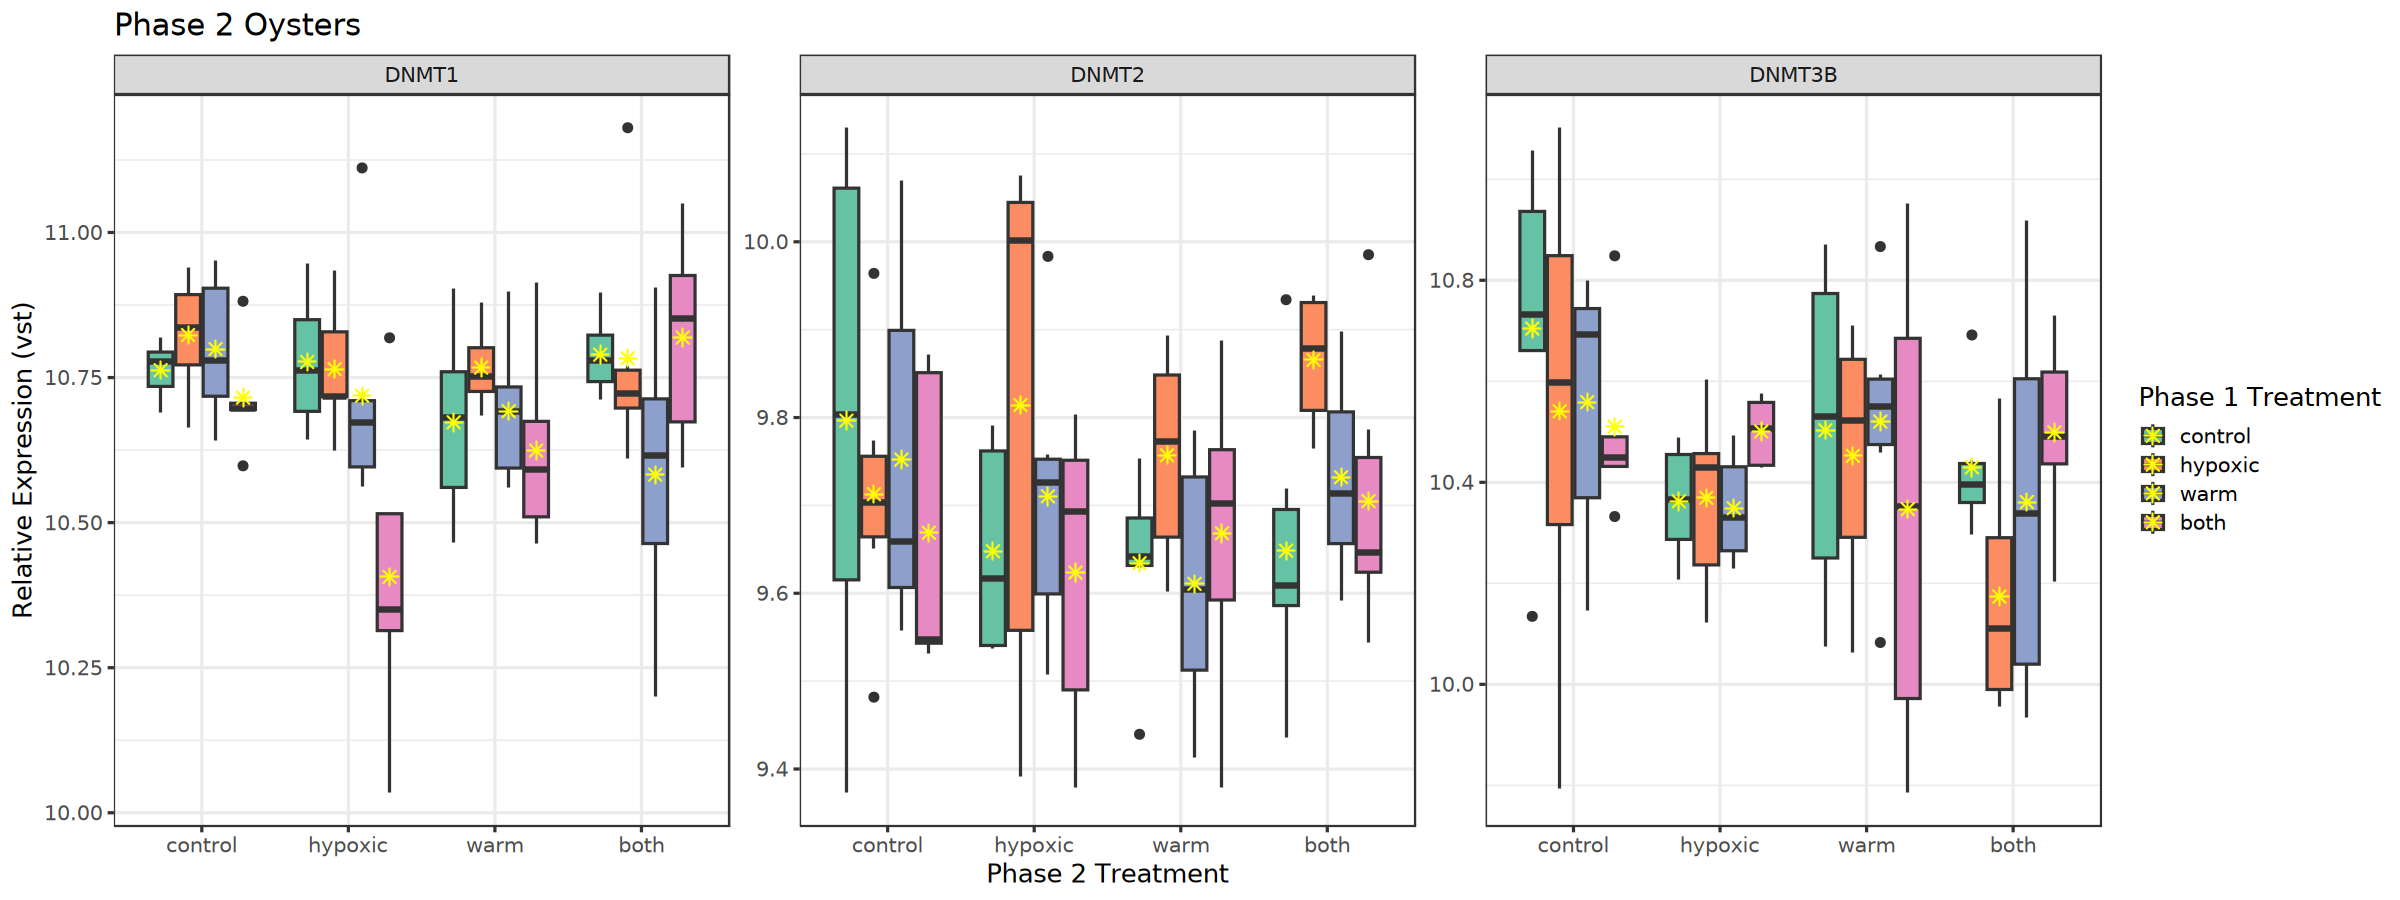

In [130]:
options(repr.plot.height = 7.5, repr.plot.width = 20)

ggplot(writer.p2,
       aes(x = Phase2_treatment, y = vst_expr, fill = Phase1_treatment)) +
geom_boxplot() +
stat_summary(
    fun = mean,
    geom = "point",
    position = position_dodge(width = 0.75),
    shape = 8,
    size = 3,
    color = "yellow"
  ) +
scale_fill_brewer(palette = 'Set2') +
facet_wrap(~gene_common, scales = 'free') +
theme_bw(base_size = 15) +
labs(
    x = 'Phase 2 Treatment',
    y = 'Relative Expression (vst)',
    fill = 'Phase 1 Treatment',
    title = 'Phase 2 Oysters'
    )

Phase 2 is the x-axis, colored by Phase 1. Yellow astericks = mean expression (mid line of boxplot = median)

**observations**:
- DNMT1 (maintenance)
    - BC and BH oysters have lower expression of DNMT1 compared to other phase 2 control and hypoxic oysters
        - early exposure to both stressors with a removal of temperature stress/return to ambient temp results in lower expression of DNMT1
        - don't need as much maintenance? bc the oyster returned to a "less stressful" state, so don't need to maintain the methylation marks from the early both environment? do we also see an increase in eraser genes for these oysters?
- DNMT2 (tRNA methylation)
    - HB has higher expression compared to the other oysters that experienced the same phase 2 treatment (both)
    - overall lower expression compared to DNMT1 and DNMT3B
- DNMT3B (de novo)
    - the effect of experiencing both stressors depends on the enviornment experienced early in life (looking at phase 2 both oysters - seems to be a lot of variation)
    - BH oysters have higher expression of DNMT3B than other oysters that experienced phase 2 hypoxia 

it might be helpful to write out **what I might expect** here:
- I would expect de novo methylation (DNMT3B) to be highest in new environments - to create a "memory" of the past
- I would expect maintenance of methylation (DNMT1) to be about the same for all treatments, or see a decrease in new environments (like rewriting the epigenetic memory to account for new environments? "unlock" genes that might be helpful in dealing with a new environment?)

### phase 1 and 2

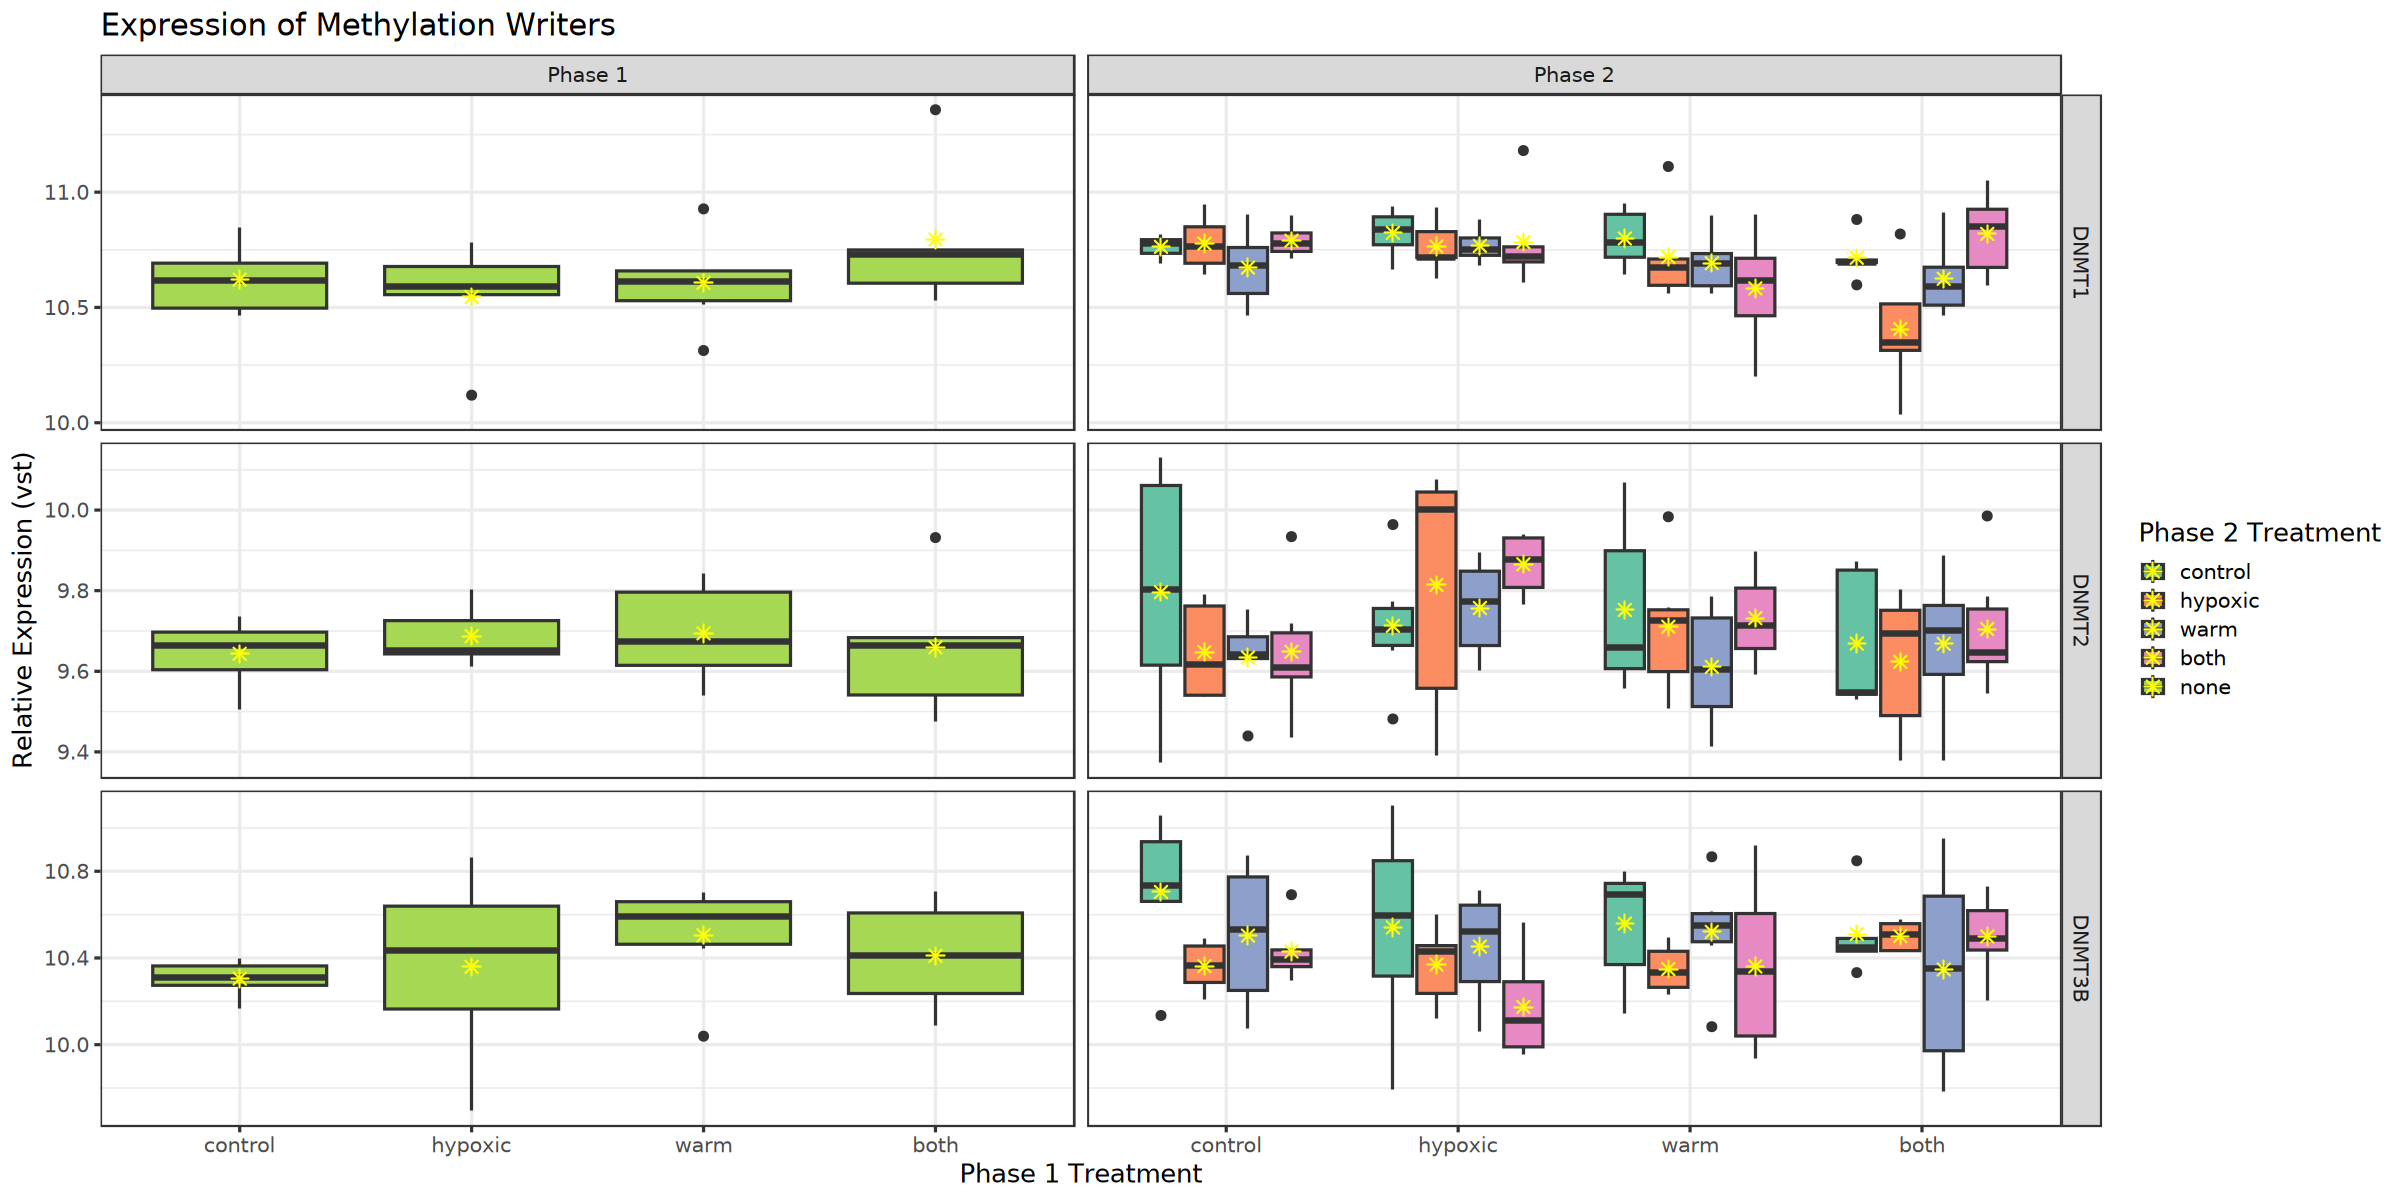

In [153]:
options(repr.plot.height = 10, repr.plot.width = 20)

# change name of the phase labels
custom_labels <- as_labeller(list(
    phase = c("Phase 1" = "Phase 1 Oysters", "Phase 2" = "Phase 2 Oysters")
))

ggplot(writer.df,
       aes(x = Phase1_treatment, y = vst_expr, fill = Phase2_treatment)) +
geom_boxplot() +
stat_summary(
    fun = mean,
    geom = "point",
    position = position_dodge(width = 0.75),
    shape = 8,
    size = 3,
    color = "yellow"
  ) +
facet_grid(gene_common ~ phase, 
           scales = 'free',
          labeller = custom_labels) +
scale_fill_brewer(palette = 'Set2') +
theme_bw(base_size = 15) +
labs(x = 'Phase 1 Treatment',
     y = 'Relative Expression (vst)',
     fill = 'Phase 2 Treatment',
    title = 'Expression of Methylation Writers')

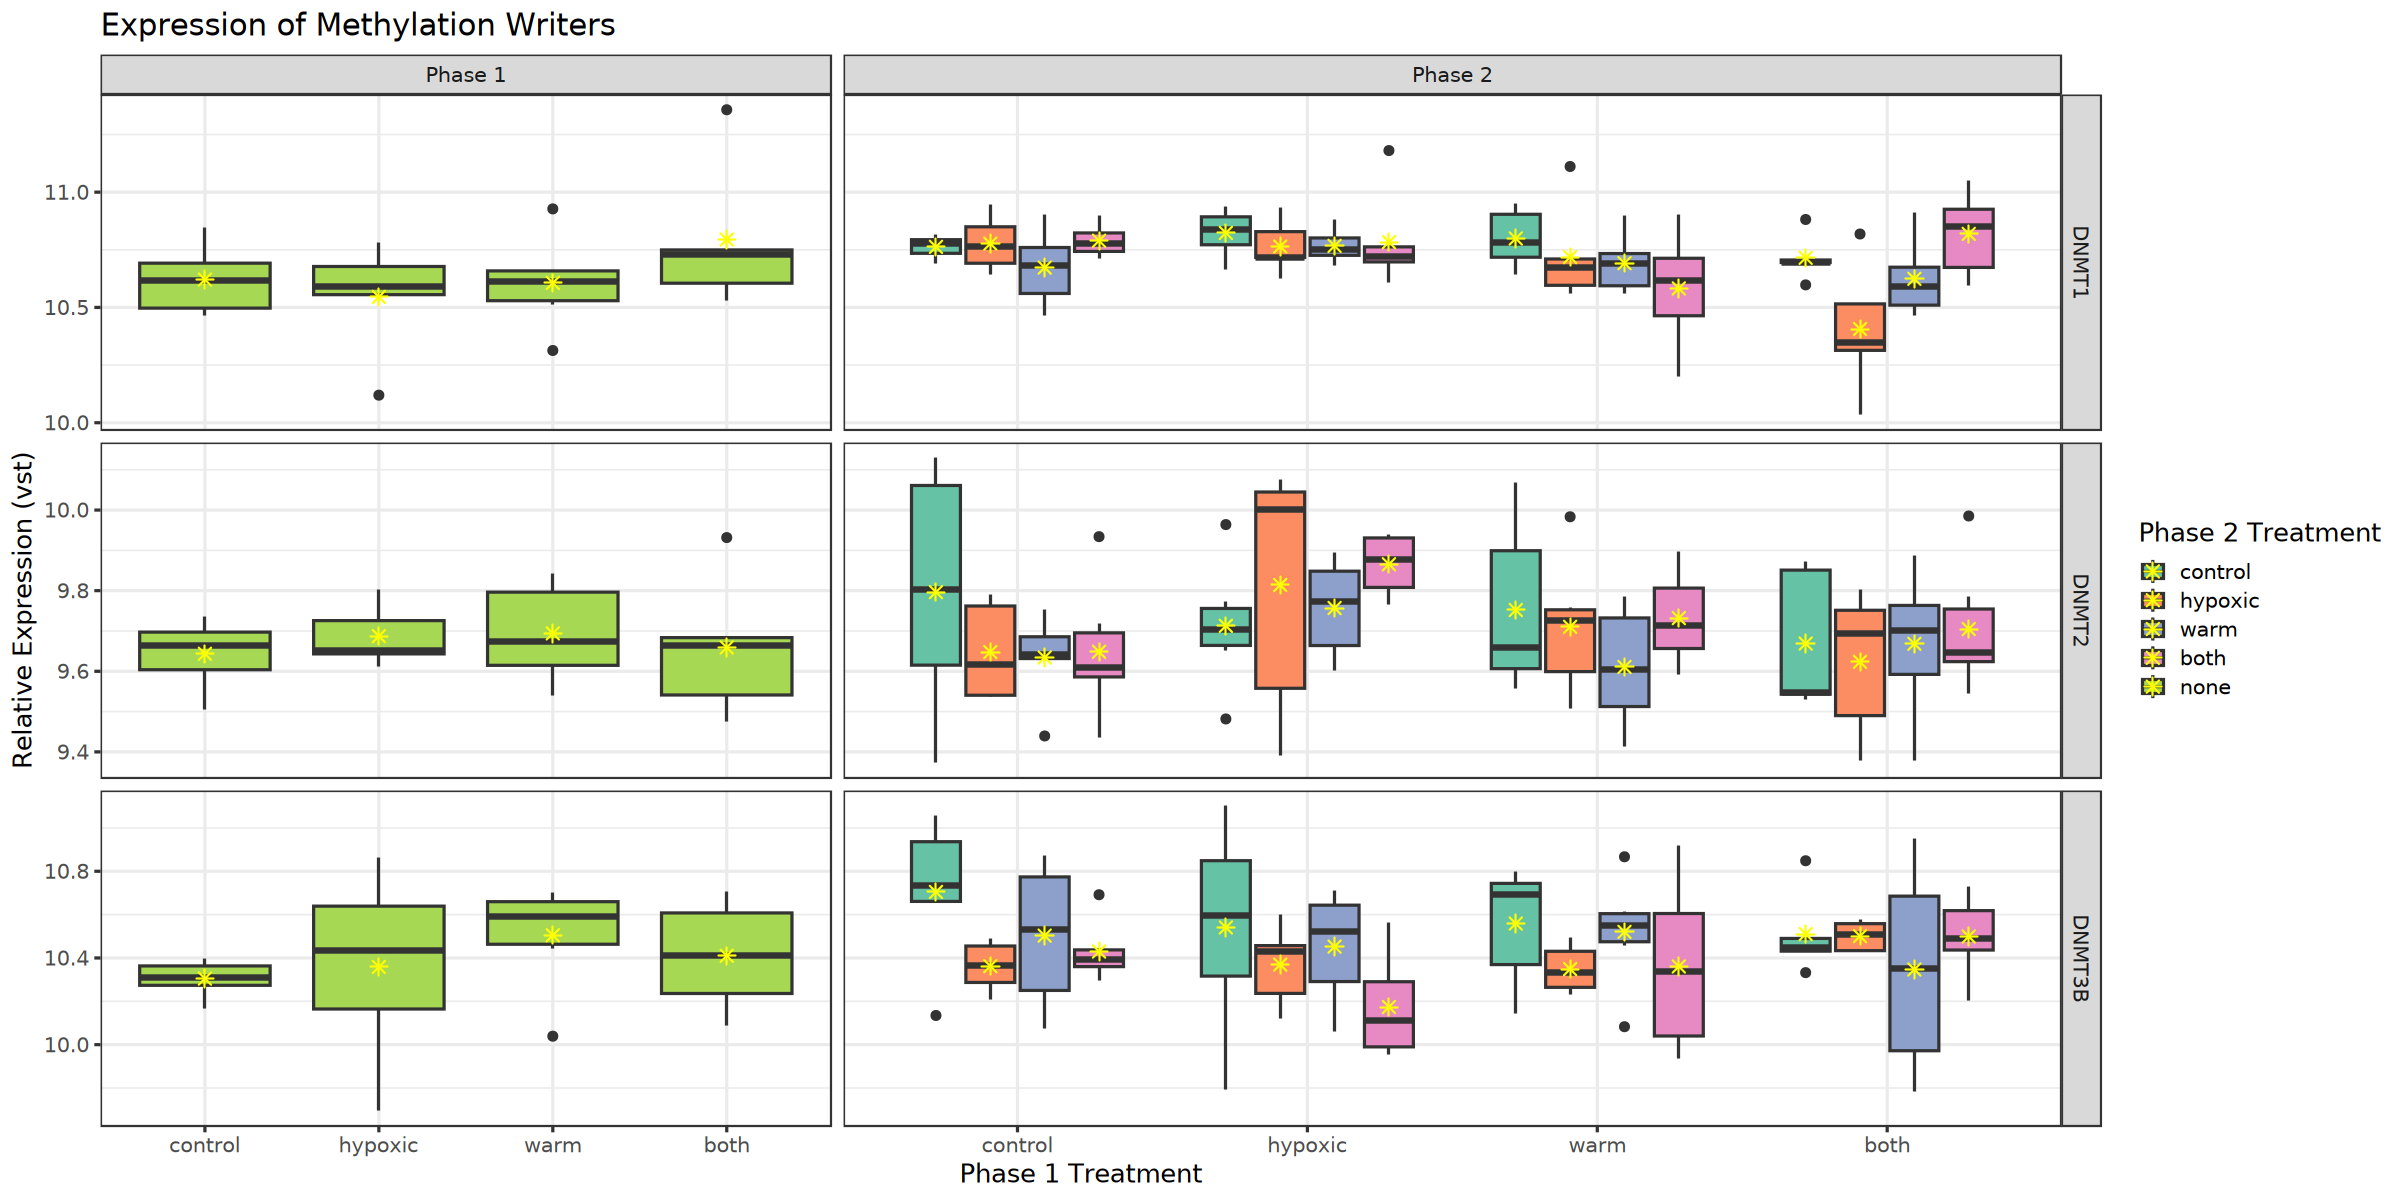

In [155]:
ggplot(writer.df,
       aes(x = Phase1_treatment, y = vst_expr, fill = Phase2_treatment)) +
  geom_boxplot() +
  stat_summary(
    fun = mean,
    geom = "point",
    position = position_dodge(width = 0.75),
    shape = 8,
    size = 3,
    color = "yellow"
  ) +
  facet_grid(gene_common ~ phase, 
             scales = 'free',
             labeller = custom_labels) +
  scale_fill_brewer(palette = 'Set2') +
  theme_bw(base_size = 15) +
  labs(x = 'Phase 1 Treatment',
       y = 'Relative Expression (vst)',
       fill = 'Phase 2 Treatment',
       title = 'Expression of Methylation Writers') +
  force_panelsizes(cols = c(0.6, 1))

it's still a little bit hard to compare phase 1 and 2 oysters here - need to think of a better visual?